<a href="https://colab.research.google.com/github/routparam12/Python_qns/blob/main/OpenCV_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [44]:
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(X_train.shape)
print(y_train.shape)

(60000, 28, 28)
(60000,)


In [45]:
digit_0 = X_train[y_train == 0][0]
digit_1 = X_train[y_train == 1][0]

print(digit_0.shape)
print(digit_1.shape)

(28, 28)
(28, 28)


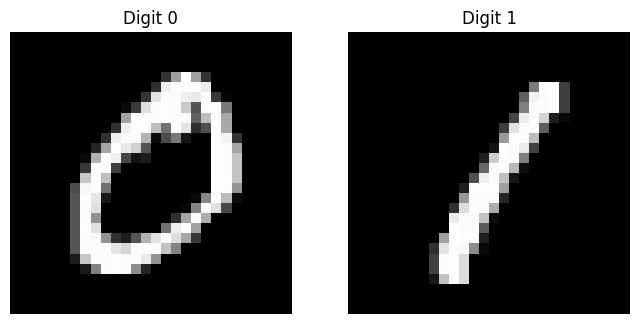

In [46]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(8, 4))

axs[0].imshow(digit_0, cmap="gray")
axs[0].set_title("Digit 0")
axs[0].axis("off")

axs[1].imshow(digit_1, cmap="gray")
axs[1].set_title("Digit 1")
axs[1].axis("off")

plt.show()

In [47]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import cv2

In [48]:
print(format(torch.__version__))

2.11.0+cu128


In [49]:
# digit_0_array_og = cv2.imread("mnist_0.jpg")
# digit_1_array_og = cv2.imread("mnist_1.jpg")

# digit_0_array_gray = cv2.imread("mnist_0.jpg",cv2.IMREAD_GRAYSCALE )
# digit_1_array_gray = cv2.imread("mnist_1.jpg",cv2.IMREAD_GRAYSCALE )

# # Visualize the image

# fig, axs = plt.subplots(1,2, figsize=(10,5))


# axs[0].imshow(digit_0_array_og, cmap='gray',interpolation='none')
# axs[0].set_title("Digit 0 Image")
# axs[0].axis('off')

# axs[1].imshow(digit_1_array_og, cmap="gray", interpolation = 'none')
# axs[1].set_title("Digit 1 Image")
# axs[1].axis('off')

# plt.show()

1.1/ Convert the numpy array to torch

torch.Size([28, 28, 3])
torch.Size([28, 28, 3])
tensor(0.)
tensor(1.)


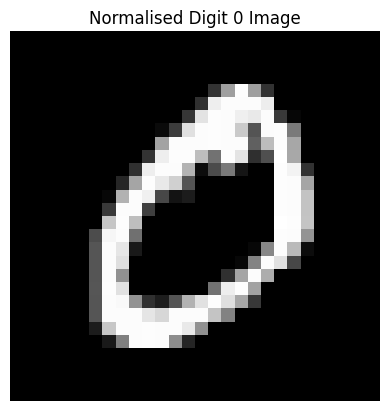

In [50]:
# Convert the image to PyTorch tensors and normalize
import torch

img_tensor_0 = torch.from_numpy(digit_0).float() / 255.0
img_tensor_1 = torch.from_numpy(digit_1).float() / 255.0

# Reshape to 28x28x3 by adding a channel dimension and repeating
img_tensor_0 = img_tensor_0.unsqueeze(2).repeat(1, 1, 3)
img_tensor_1 = img_tensor_1.unsqueeze(2).repeat(1, 1, 3)

print(img_tensor_0.shape)
print(img_tensor_1.shape)
print(torch.min(img_tensor_0))
print(torch.max(img_tensor_0))


plt.imshow(img_tensor_0,cmap="gray")
plt.title("Normalised Digit 0 Image")
plt.axis('off')
plt.show()

##1.2/ Creating Input batch

In [51]:
batch_tensor = torch.stack([img_tensor_0, img_tensor_1])


#In pytorch the forward pass of input images is expected to have a batch_size > 1
print(batch_tensor.shape)

torch.Size([2, 28, 28, 3])


Additionally in PyTorch, image tensors typically follow the shape convention [N ,C ,H ,W] unlike tensorflow which follows [N, H, W, C].

Therefore, we need to bring the color channel to the second dimension. This can be achieved using either torch.view() or torch.permute().

In [52]:
batch_input = batch_tensor.permute(0,1,2,3)
print("Batch Tensor Shape:", batch_input.shape)

Batch Tensor Shape: torch.Size([2, 28, 28, 3])


##2. Introduction to Tensors and its Operations
We have seen the importance of tensors, now will understand it from ground up. Tensor is simply a fancy name given to matrices. If you are familiar with NumPy arrays, understanding and using PyTorch Tensors will be very easy. A scalar value is represented by a 0-dimensional Tensor. Similarly, a column/row matrix is represented using a 1-D Tensor and so on. Some examples of Tensors with different dimensions are shown for you to visualize and understand.

<img src=https://learnopencv.com/wp-content/uploads/2019/05/PyTorch-Tensors.jpg width = 400 height=350>

## 2.1. Construct your first Tensor

Let’s see how we can create a PyTorch Tensor.

In [53]:
# Create a Tensor with just ones in a column
a = torch.ones(5)
# Print the tensor we created
print(a)

# Create a Tensor with just zeros in a column
b = torch.zeros(5)
print(b)

tensor([1., 1., 1., 1., 1.])
tensor([0., 0., 0., 0., 0.])


We can similarly create Tensor with custom values as shown below.

In [54]:
c = torch.tensor([1.0, 2.0, 3.0, 4.0, 5.0])
print(c)

tensor([1., 2., 3., 4., 5.])


In all the above cases, we have created vectors or Tensors of dimension 1. Now, let’s create some tensors of higher dimension.

In [55]:
d = torch.zeros(3,2)
print(d)

e = torch.ones(3,2)
print(e)

f = torch.tensor([[1.0, 2.0],[3.0, 4.0]])
print(f)

# 3D Tensor
g = torch.tensor([[[1., 2.], [3., 4.]], [[5., 6.], [7., 8.]]])
print(g)

tensor([[0., 0.],
        [0., 0.],
        [0., 0.]])
tensor([[1., 1.],
        [1., 1.],
        [1., 1.]])
tensor([[1., 2.],
        [3., 4.]])
tensor([[[1., 2.],
         [3., 4.]],

        [[5., 6.],
         [7., 8.]]])


In [56]:
print(f.shape)


torch.Size([2, 2])


2.2. Access an element in Tensor
Now that we have created some tensors, let’s see how we can access an element in a Tensor. First let’s see how to do this for 1D Tensor aka vector.

In [57]:
# Get element at index 2
print(c[2])

tensor(3.)


What about 2D or 3D Tensor? Recall what we mentioned about dimension of a tensor.

To access one particular element in a tensor, we will need to specify indices equal to the dimension of the tensor. That’s why for tensor c we only had to specify one index.

In [58]:
# All indices starting from 0

# Get element at row 1, column 0
print(f[1,0])

# We can also use the following
print(f[1][0])

# Similarly for 3D Tensor
print(g[1,0,0])
print(g[1][0][0])

tensor(3.)
tensor(3.)
tensor(5.)
tensor(5.)


But what if you wanted to access one entire row in a 2D Tensor?

In [59]:
# All elements
print(f[:])

# All elements from index 1 to 2 (excluding element 3)
print(c[1:3])

# All elements till index 4 (exclusive)
print(c[:4])

# First row
print(f[0, :])

# Second column
print(f[:,1])

tensor([[1., 2.],
        [3., 4.]])
tensor([2., 3.])
tensor([1., 2., 3., 4.])
tensor([1., 2.])
tensor([2., 4.])


2.3. Specify data type of elements
Whenever we create a tensor, PyTorch decides the data type of the elements of the tensor such that the data type can cover all the elements of the tensor. We can override this by specifying the data type while creating the tensor.

In [60]:
int_tensor = torch.tensor([[1,2,3],[4,5,6]])
print(int_tensor.dtype)

# What if we changed any one element to floating point number?
int_tensor = torch.tensor([[1,2,3],[4.,5,6]])
print(int_tensor.dtype)
print(int_tensor)

# This can be overridden as follows
float_tensor = torch.tensor([[1, 2, 3],[4., 5, 6]])
int_tensor = float_tensor.type(torch.int64)
print(int_tensor.dtype)
print(int_tensor)

torch.int64
torch.float32
tensor([[1., 2., 3.],
        [4., 5., 6.]])
torch.int64
tensor([[1, 2, 3],
        [4, 5, 6]])


2.4. Tensor to/from NumPy Array
We have mentioned several times that PyTorch Tensors and NumPy arrays are pretty similar. This of course demands the question if it’s possible to convert one data structure into another. Let’s see how we can do this.

In [61]:
# Tensor to Array
f_numpy = f.numpy()
print(f_numpy)

# Array to Tensor
h = np.array([[8,7,6,5],[4,3,2,1]])
h_tensor = torch.from_numpy(h)
print(h_tensor)

[[1. 2.]
 [3. 4.]]
tensor([[8, 7, 6, 5],
        [4, 3, 2, 1]])


2.5. Arithmetic Operations on Tensors
Now it’s time for the next step. Let’s see how we can perform arithmetic operations on PyTorch tensors.

In [62]:
# Create tensor
tensor1 = torch.tensor([[1,2,3],[4,5,6]])
tensor2 = torch.tensor([[-1,2,-3],[4,-5,6]])

# Addition
print(tensor1+tensor2)
# We can also use
print(torch.add(tensor1,tensor2))

# Subtraction
print(tensor1-tensor2)
# We can also use
print(torch.sub(tensor1,tensor2))

# Multiplication
# Tensor with Scalar
print(tensor1 * 2)

# Tensor with another tensor
# Elementwise Multiplication
print(tensor1 * tensor2)

# Matrix multiplication
tensor3 = torch.tensor([[1,2],[3,4],[5,6]])
print(torch.mm(tensor1,tensor3))

# Division
# Tensor with scalar
print(tensor1/2)

# Tensor with another tensor
# Elementwise division
print(tensor1/tensor2)

tensor([[ 0,  4,  0],
        [ 8,  0, 12]])
tensor([[ 0,  4,  0],
        [ 8,  0, 12]])
tensor([[ 2,  0,  6],
        [ 0, 10,  0]])
tensor([[ 2,  0,  6],
        [ 0, 10,  0]])
tensor([[ 2,  4,  6],
        [ 8, 10, 12]])
tensor([[ -1,   4,  -9],
        [ 16, -25,  36]])
tensor([[22, 28],
        [49, 64]])
tensor([[0.5000, 1.0000, 1.5000],
        [2.0000, 2.5000, 3.0000]])
tensor([[-1.,  1., -1.],
        [ 1., -1.,  1.]])


##2.6. Broadcasting
a) is a 1-dimensional tensor with shape ([ 3 ]).

b) is a scalar tensor with shape ([ 1 ]).
When adding a and b, PyTorch broadcasts b to match the shape of a, resulting in ([ 1 + 4, 2 + 4, 3 + 4 ]).

In [63]:
# Create two 1-dimensional tensors
a = torch.tensor([1, 2, 3])
b = torch.tensor([4])

# adding a scalar to a vector
result = a + b

print("Result of Broadcasting:\n",result)

Result of Broadcasting:
 tensor([5, 6, 7])


[Broadcasting](https://pytorch.org/docs/stable/notes/broadcasting.html#broadcasting-semantics) allows PyTorch to perform element-wise operations on tensors of
   - `a` is a 2-dimensional tensor with shape \([1, 3]\).
   - `b` is a 2-dimensional tensor with shape \([3, 1]\).
   - When adding `a` and `b`, PyTorch broadcasts both tensors to the common shape \([3, 3]\), resulting in:
   
     \
     \begin{bmatrix}
     1+4 & 2+4 & 3+4 \\
     1+5 & 2+5 & 3+5 \\
     1+6 & 2+6 & 3+6 \\
     \end{bmatrix}
     \.

In [64]:
# Create two tensors with shapes (1, 3) and (3, 1)
a = torch.tensor([[1, 2, 3]])
b = torch.tensor([[4], [5], [6]])

# adding tensors of different shapes
result = a + b
print("Shape: ", result.shape)
print("\n")
print("Result of Broadcasting:\n", result)

Shape:  torch.Size([3, 3])


Result of Broadcasting:
 tensor([[5, 6, 7],
        [6, 7, 8],
        [7, 8, 9]])


##2.7. CPU v/s GPU Tensor
Let’s first see how to create a tensor for GPU.

In [65]:
# Create a tensor for CPU
# This will occupy CPU RAM
tensor_cpu = torch.tensor([[1.0, 2.0], [3.0, 4.0], [5.0, 6.0]], device='cpu')

# Create a tensor for GPU
# This will occupy GPU RAM
tensor_gpu = torch.tensor([[1.0, 2.0], [3.0, 4.0], [5.0, 6.0]], device='cuda')

Just like tensor creation, the operations performed for CPU and GPU tensors are also different and consume RAM corresponding to the device specified.

In [66]:
# This uses CPU RAM
tensor_cpu = tensor_cpu * 5

# This uses GPU RAM
# Focus on GPU RAM Consumption
tensor_gpu = tensor_gpu * 5

We can move the GPU tensor to CPU and vice versa as shown below.




In [67]:
# Move GPU tensor to CPU
tensor_gpu_cpu = tensor_gpu.to(device='cpu')

# Move CPU tensor to GPU
tensor_cpu_gpu = tensor_cpu.to(device='cuda')

##3. Conclusion
In this notebook, we started with constructing simple tensors and manipulating them. Next notebook, we will understand the functionality of Torch Autograd and its role in automatic differentiation and gradient computation. In the upcoming notebooks, we will go deeper into backpropagation and various computer vision tasks such as Classification, Segmentation, Object Detection, and Instance Segmentation. Each notebook will provide a detailed explanation and hands-on examples to help you serve as starter notebooks to master the essential tasks in computer vision.

##1.1. torch.autograd



- We create two tensors `x` and `y` with `requires_grad=True`, indicating that we want to compute gradients for these tensors.



- We perform simple operations on `x` and `y` to obtain `z`.

- Computing Gradients:
We call `z.backward()` to compute the gradients of `z` with respect to `x` and `y`. The gradients are stored in the `grad` attribute of each tensor.




In the following example:


- The operation is $ z = x \cdot y + y^2 $.
- The partial derivative of $ z $ with respect to $ x $ is $ \frac{\partial z}{\partial x} = y $.
- The partial derivative of $ z $ with respect to $ y $ is $ \frac{\partial z}{\partial y} = x + 2y $.

Given $ x = 2.0 $ and $ y = 3.0 $:

- The gradient of $ z $ w.r.t. $ x $ is $ 3.0 $.
- The gradient of $ z $ w.r.t. $ y $ is $ 2.0 + 2 \cdot 3.0 = 8.0 $.

Tensors that require gradients will have their operations tracked by PyTorch's autograd engine, enabling the computation of gradients during backpropagation.


<img src=https://learnopencv.com/wp-content/uploads/2024/07/Autograd-Computation-Graph-2-2.png height = 500>


The automatic differentiation provided by `torch.autograd` simplifies this process by handling the complex chain rule calculations needed for backpropagation through the entire network.






For $\frac{\partial z}{\partial x}$:

$$\frac{\partial z}{\partial x} = \frac{\partial z}{\partial p} \frac{\partial p}{\partial x} + \frac{\partial z}{\partial q} \frac{\partial q}{\partial x} = 1 \cdot y + 1 \cdot 0 = y$$

For $\frac{\partial z}{\partial y}$:

$$\frac{\partial z}{\partial y} = \frac{\partial z}{\partial p} \frac{\partial p}{\partial y} + \frac{\partial z}{\partial q} \frac{\partial q}{\partial y} = 1 \cdot x + 1 \cdot 2y = x + 2y$$

These equations correspond to the chain rule calculations happening behind the scenes, demonstrating how PyTorch's autograd system computes gradients through the computational graph.

Autograd- Pytorch

In [68]:
# Create tensors with requires_grad=True
x = torch.tensor([2.0, 5.0], requires_grad=True)
y = torch.tensor([3.0, 7.0], requires_grad=True)

# Perform some operations
z = x * y + y**2

z.retain_grad() #By default intermediate layer weight updation is not shown.

# Compute the gradients
z_sum = z.sum().backward()


print(f"Gradient of x: {x.grad}")
print(f"Gradient of y: {y.grad}")
print(f"Gradient of z: {z.grad}")
print(f"Result of the operation: z = {z.detach()}")

Gradient of x: tensor([3., 7.])
Gradient of y: tensor([ 8., 19.])
Gradient of z: tensor([1., 1.])
Result of the operation: z = tensor([15., 84.])


## 1.2. Gradient Computation Graph


A computation graph is a visual representation of the sequence of operations performed on tensors in a neural network, showing how each operation contributes to the final result. It is crucial for understanding and debugging the flow of data and gradients in deep learning models.
[torchviz](https://github.com/szagoruyko/pytorchviz) is a tool used to visualize the computation graph of any PyTorch model.


<img src=https://learnopencv.com/wp-content/uploads/2024/07/Autograd-Operators-Graph-1-1.png height = 500 >

In [70]:
!pip install torchviz

In [71]:
from torchviz import make_dot

# Visualize the computation graph
dot = make_dot(z, params={"x": x, "y": y, "z" : z})
dot.render("grad_computation_graph", format="png")

'grad_computation_graph.png'

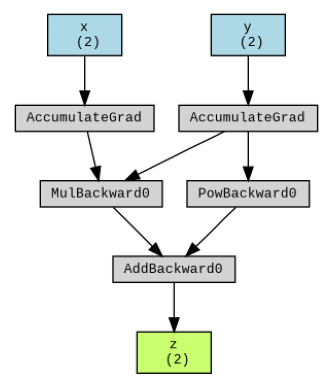

In [72]:
img = plt.imread("grad_computation_graph.png")
plt.imshow(img)
plt.axis('off')
plt.show()

##1.3. Detaching Tensors from Computation Graph
The detach() method is used to create a new tensor that shares storage with the original tensor but without tracking operations. When you call detach(), it returns a new tensor that does not require gradients. This is useful when you want to perform operations on a tensor without affecting the computation graph.

In [73]:
# Let's detach z from the computation graph
print("Before detaching z from computation: ", z.requires_grad)
z_det = z.detach()
print("After detaching z from computation: ", z_det.requires_grad)

Before detaching z from computation:  True
After detaching z from computation:  False


##1.4. Can Backpropagation be performed when requires_grad=False?
Now the same tensors x and y are created with requires_grad=False.

When attempting to compute the gradients using z.backward(), a RuntimeError is raised because the tensors do not require gradients, and thus do not have a grad_fn.

In this case, since requires_grad=False was used, the computation graph is essentially empty, as no gradients will be tracked.

In [74]:
x = torch.tensor(2.0, requires_grad=False)
y = torch.tensor(3.0, requires_grad=False)


# Perform simple operations
z = x * y + y**2


# Compute the gradients
z.backward()

RuntimeError: element 0 of tensors does not require grad and does not have a grad_fn

# 2. Backpropagation in Neural Networks

<img src=https://learnopencv.com/wp-content/uploads/2017/10/gradient-descent-2d-diagram.png>

We have understood the mathematical intuition behind and how **torch.autograd** takes care of automatic differentiation with an example.

Then,
 * The loss is calculate between prediction and target using `loss(predcition,target`)
 * Then backpropagation is performed using `loss.backward()`
 * We update the new weights using `optimizer.step()`

<img src=https://learnopencv.com/wp-content/uploads/2023/01/keras-linear-regression-weight-update-block-diagram.png>


**The Weight Update Formula is:**


$$ \mathbf{w}_{\text{new}} = \mathbf{w} - \eta \nabla L(\mathbf{w}) $$

The gradient of $ L $ is a vector of partial derivatives:

$$ \nabla L = \left( \frac{\partial L}{\partial w_1}, \frac{\partial L}{\partial w_2}, \ldots, \frac{\partial L}{\partial w_n} \right) $$

- **Current Weights $( \mathbf{w} )$**: These are the weights of the model before the update.
- **Learning Rate $( \eta )$**: A hyperparameter that controls the step size of the weight update. A smaller learning rate makes the training process slower but more precise, while a larger learning rate makes the training process faster but it may sometimes overshoot the optimal solution.
- **Gradient of the Loss $( \nabla L(\mathbf{w}) )$**: The partial derivatives of the loss function with respect to each weight. This indicates the direction and magnitude of the steepest ascent in the loss function.
- **Updated Weights $(\mathbf{w}_{\text{new}} )$**: The new weights after applying the gradient descent step.


After applying the updates, it's crucial to zero out the gradients. This is typically done using: `optimizer.zero_grad()`

